In [2]:
!pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("Cardiotocographic.csv")

In [6]:
df.shape

(2126, 14)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   LB        2105 non-null   float64
 1   AC        2106 non-null   float64
 2   FM        2126 non-null   float64
 3   UC        2126 non-null   float64
 4   DL        2126 non-null   float64
 5   DS        2105 non-null   float64
 6   DP        2105 non-null   float64
 7   ASTV      2126 non-null   float64
 8   MSTV      2126 non-null   float64
 9   ALTV      2126 non-null   float64
 10  MLTV      2105 non-null   float64
 11  Width     2105 non-null   float64
 12  Tendency  2105 non-null   float64
 13  NSP       2105 non-null   float64
dtypes: float64(14)
memory usage: 232.7 KB


In [8]:
df.isnull().sum()

LB          21
AC          20
FM           0
UC           0
DL           0
DS          21
DP          21
ASTV         0
MSTV         0
ALTV         0
MLTV        21
Width       21
Tendency    21
NSP         21
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(2)

In [10]:
df.describe()

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
count,2105.000000,2106.000000,2126.000000,2126.000000,2126.000000,2105.000000,2105.000000,2126.000000,2126.000000,2126.000000,2105.000000,2105.000000,2105.000000,2105.000000
mean,133.343598,0.003219,0.009894,0.004391,0.001895,0.000003,0.000175,46.995984,1.364378,10.285964,8.284887,70.429260,0.316371,1.304507
std,11.270154,0.004391,0.067540,0.003340,0.003343,0.000142,0.000840,18.813973,1.173632,21.205041,7.772858,42.931822,0.645622,0.644619
min,51.842487,-0.019284,-0.480634,-0.014925,-0.015393,-0.001353,-0.005348,-63.000000,-6.600000,-91.000000,-50.700000,-174.000000,-3.000000,-1.025988
25%,126.000000,0.000000,0.000000,0.001851,0.000000,0.000000,0.000000,32.000000,0.700000,0.000000,4.600000,37.000000,0.000000,1.000000
50%,133.000000,0.001634,0.000000,0.004484,0.000000,0.000000,0.000000,49.000000,1.200000,0.000000,7.400000,67.000000,0.000000,1.000000
75%,140.000000,0.005650,0.002567,0.006536,0.003289,0.000000,0.000000,61.000000,1.700000,11.000000,10.900000,100.000000,1.000000,1.000000
max,214.000000,0.038567,0.961268,0.030002,0.030769,0.002706,0.010695,162.000000,13.800000,182.000000,101.400000,357.000000,3.000000,5.000000


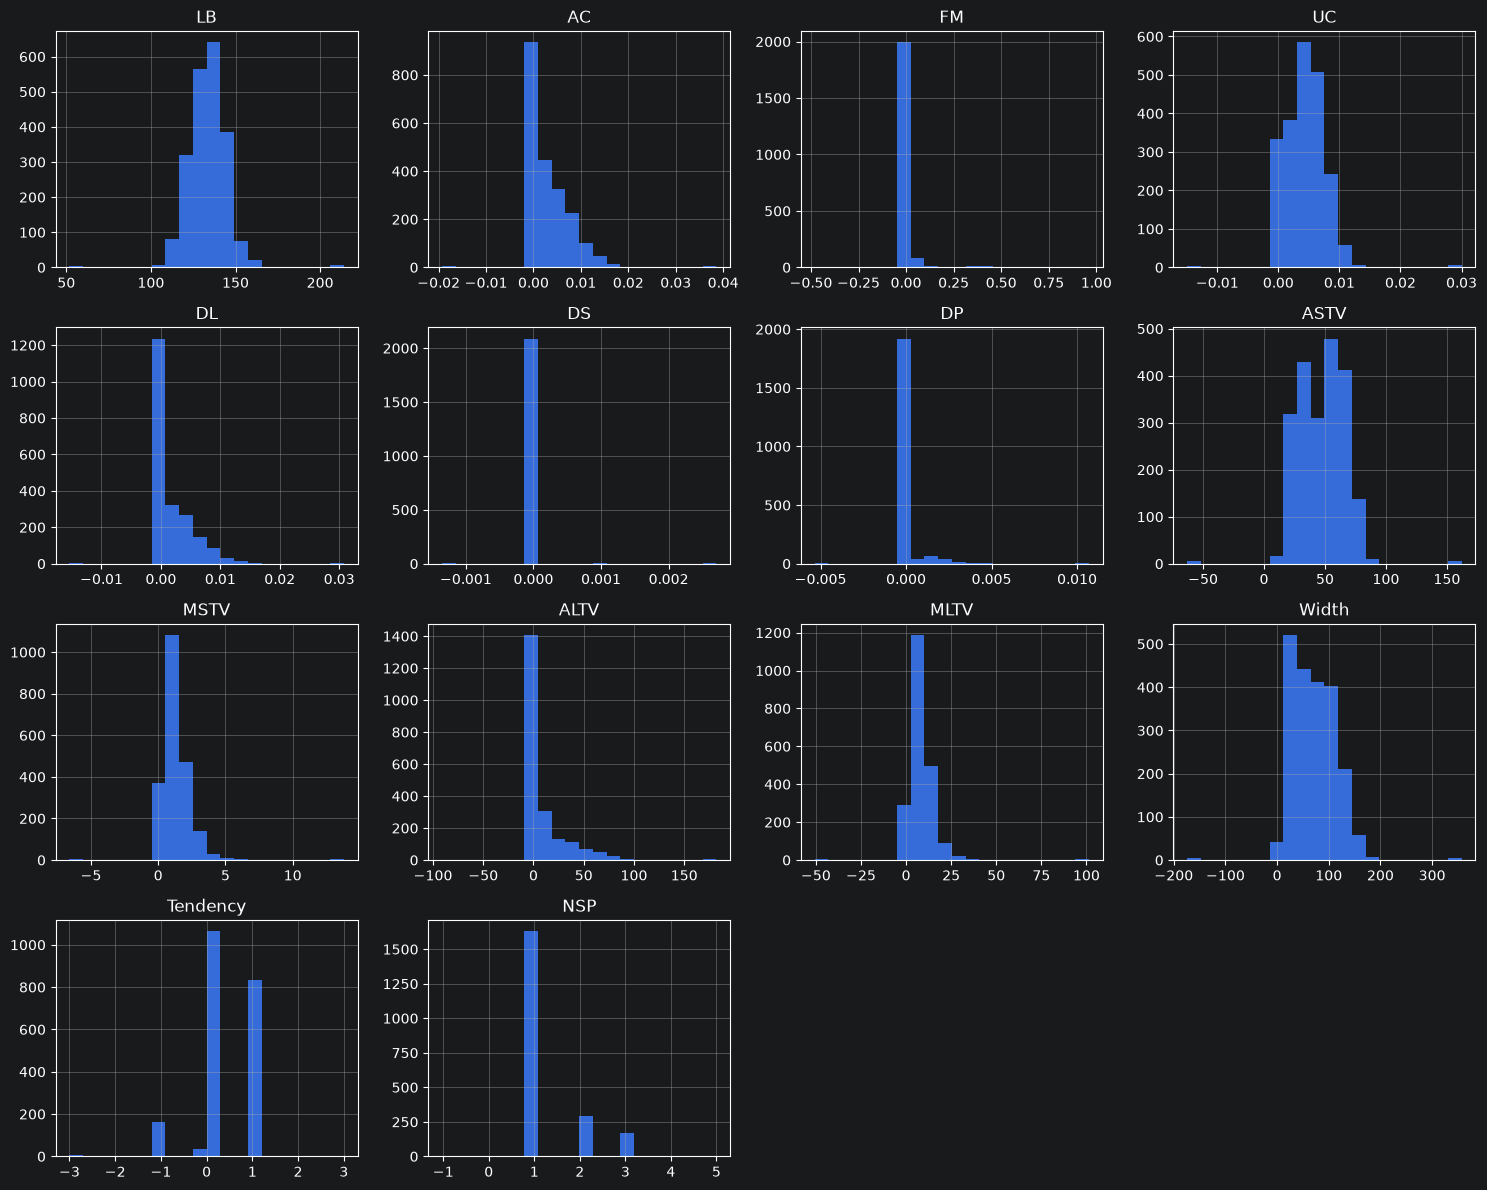

In [11]:
df.hist(figsize=(15, 12), bins=20)
plt.tight_layout()
plt.show()

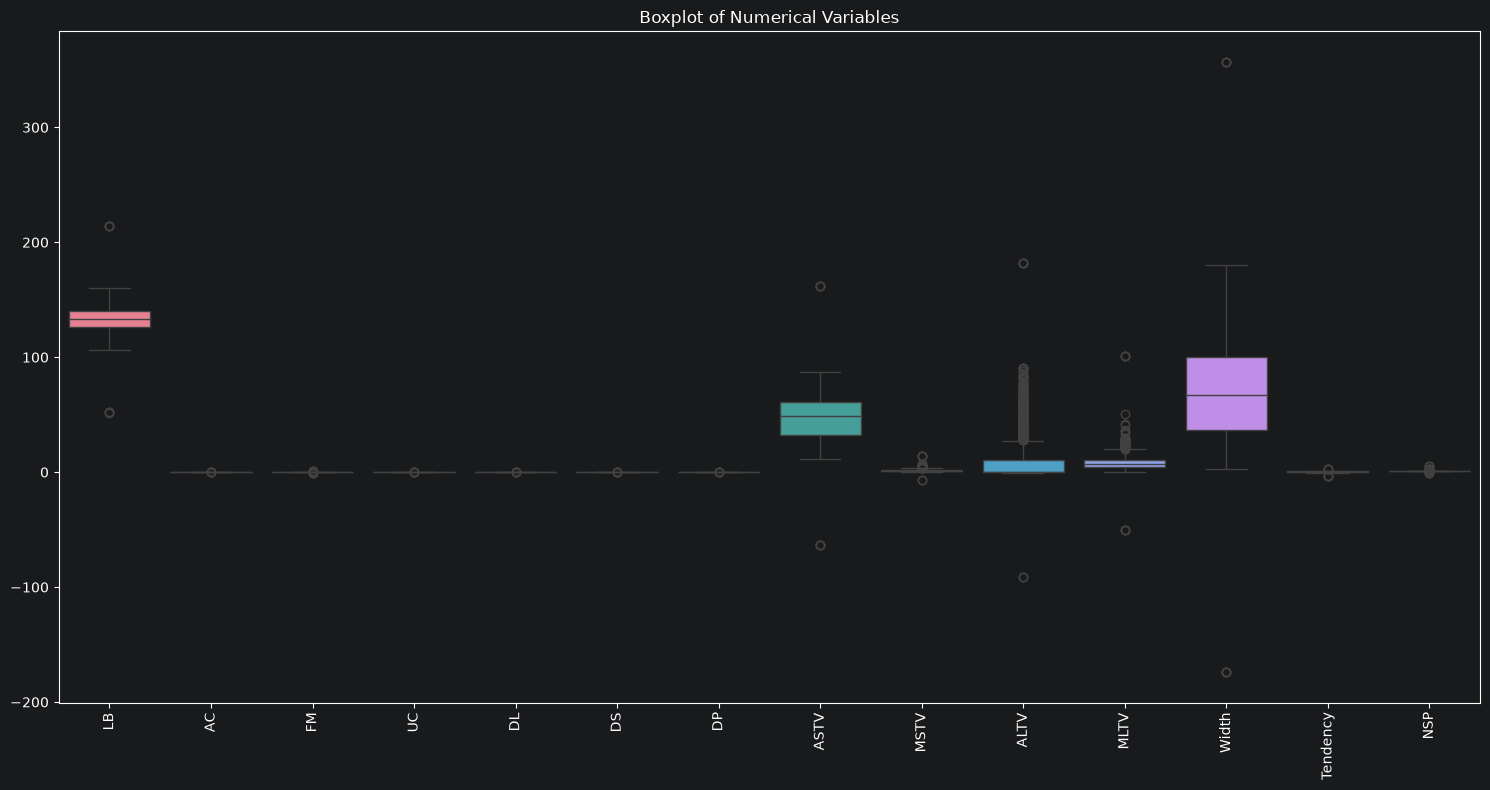

In [12]:
plt.figure(figsize=(15, 8))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.title("Boxplot of Numerical Variables")
plt.tight_layout()
plt.show()

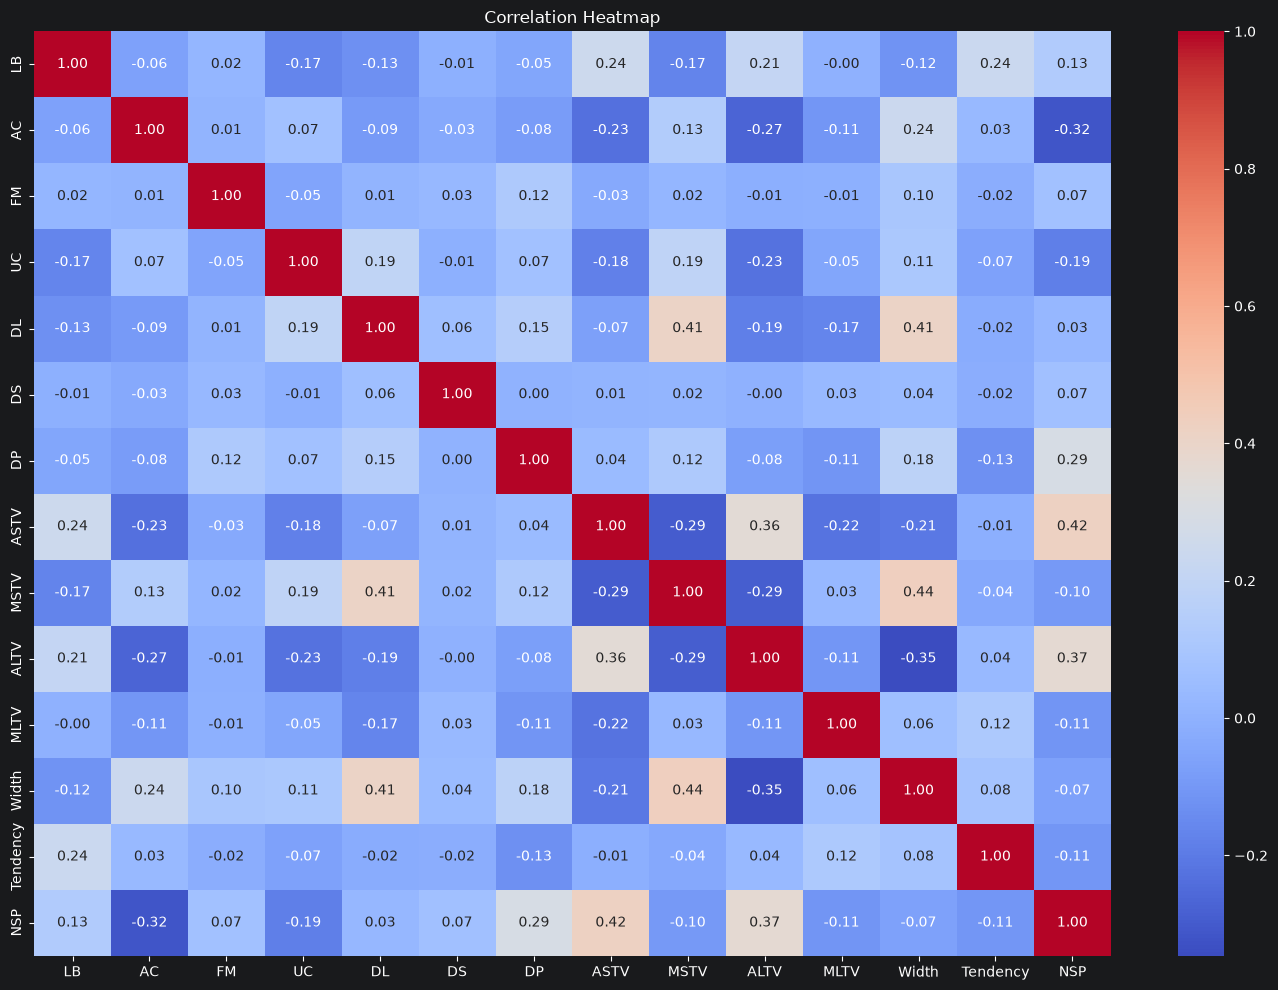

In [13]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

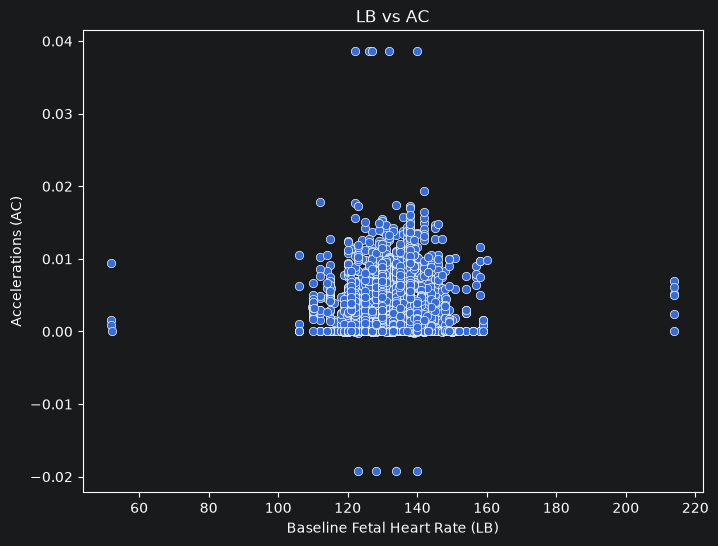

In [14]:
plt.figure(figsize=(8, 6))

sns.scatterplot(data=df, x="LB", y="AC")

plt.title("LB vs AC")
plt.xlabel("Baseline Fetal Heart Rate (LB)")
plt.ylabel("Accelerations (AC)")
plt.show()

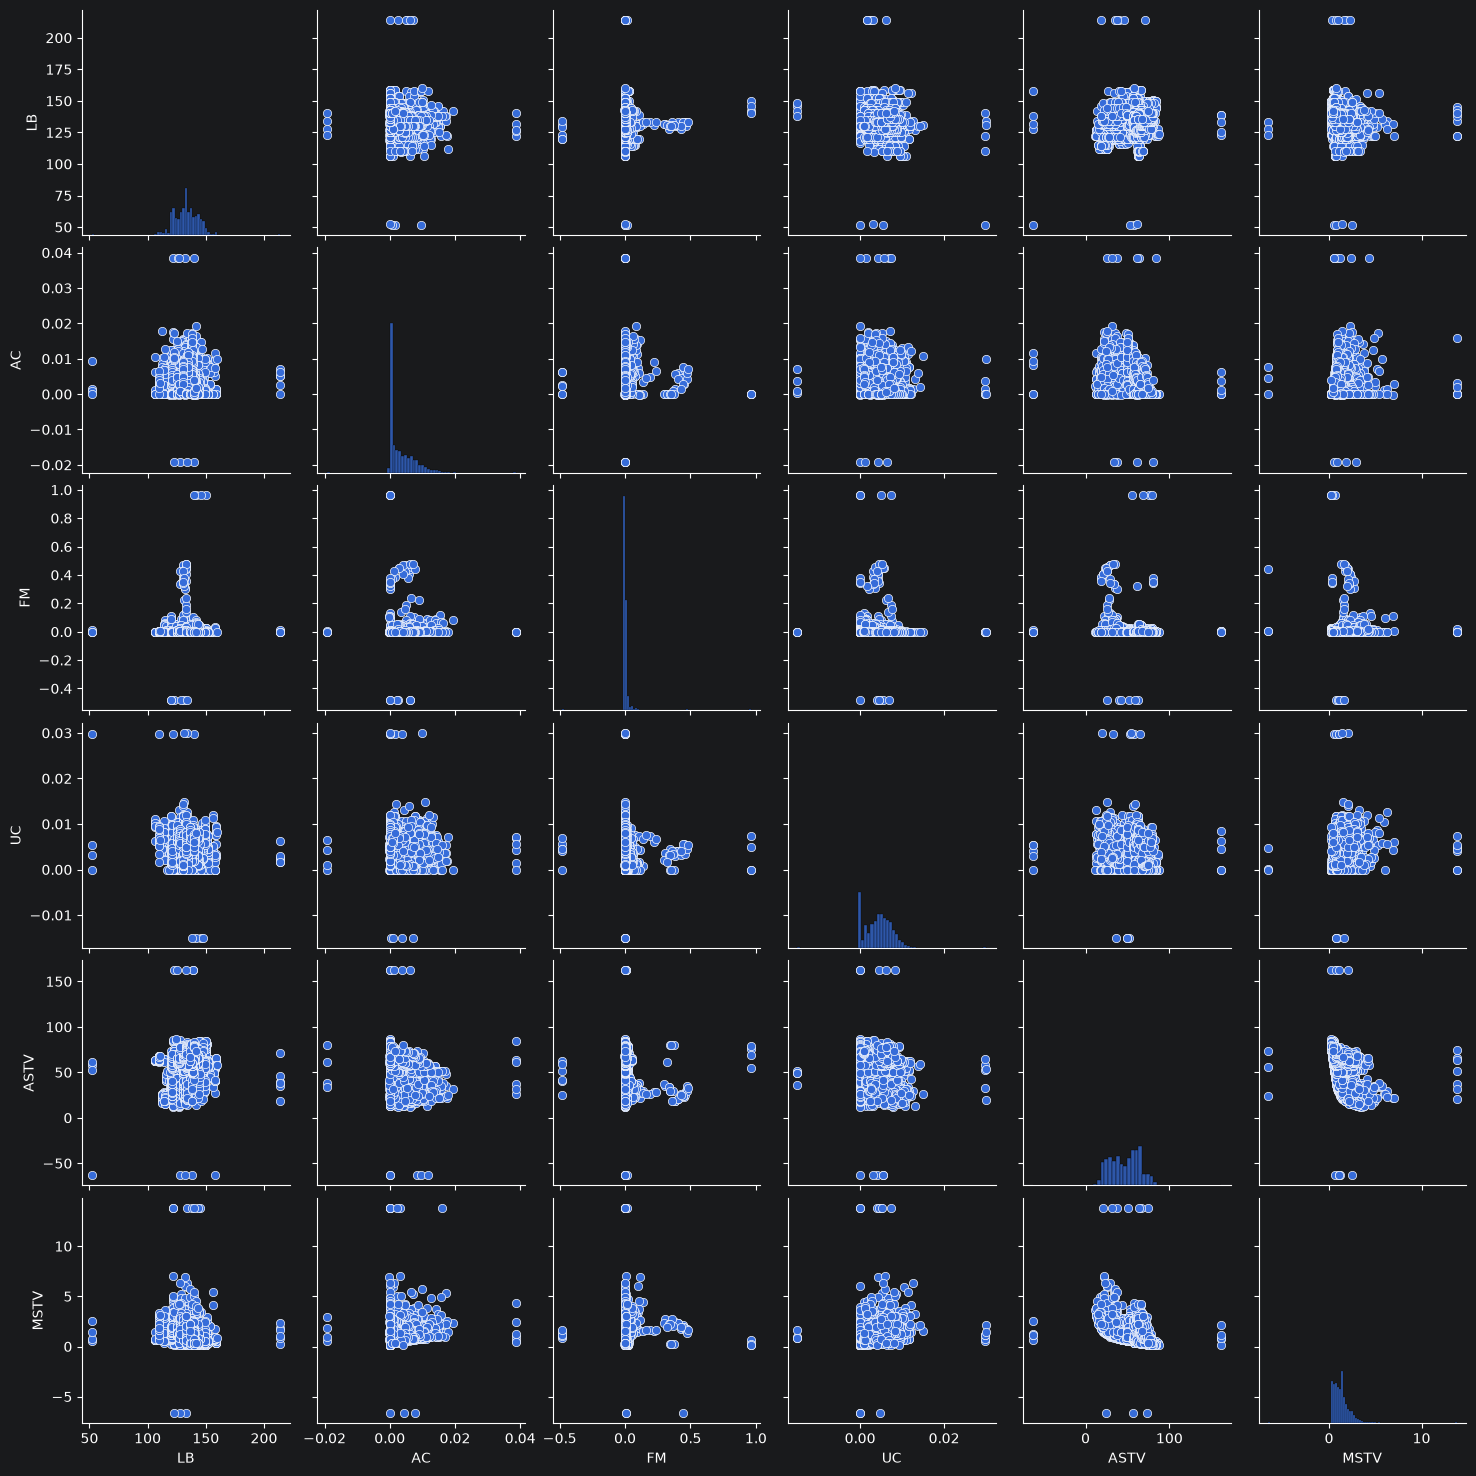

In [15]:
selected_columns = ["LB", "AC", "FM", "UC", "ASTV", "MSTV"]

sns.pairplot(df[selected_columns])
plt.show()

In [16]:
Q1 = df.quantile(0.25, numeric_only=True)
Q3 = df.quantile(0.75, numeric_only=True)

IQR = Q3 - Q1

outliers = ((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).sum()

outliers

LB           10
AC           40
FM          347
UC           13
DL          125
DS          120
DP          284
ASTV         10
MSTV         80
ALTV        318
MLTV         81
Width        10
Tendency     10
NSP         559
dtype: int64

In [17]:
df.dtypes

LB          float64
AC          float64
FM          float64
UC          float64
DL          float64
DS          float64
DP          float64
ASTV        float64
MSTV        float64
ALTV        float64
MLTV        float64
Width       float64
Tendency    float64
NSP         float64
dtype: object

In [18]:
df.nunique()


LB           153
AC          1067
FM           776
UC          1364
DL           822
DS           114
DP           264
ASTV         183
MSTV         165
ALTV         195
MLTV         351
Width        261
Tendency     111
NSP          111
dtype: int64

In [19]:
df.head()

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
0,120.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,73.0,0.5,43.0,2.4,64.0,0.999926,2.0
1,132.000000,0.006380,0.0,0.006380,0.003190,0.0,0.0,17.0,2.1,0.0,10.4,130.0,0.000000,1.0
2,133.000000,0.003322,0.0,0.008306,0.003322,0.0,0.0,16.0,2.1,0.0,13.4,130.0,0.000000,1.0
3,134.000000,0.002561,0.0,0.007742,0.002561,0.0,0.0,16.0,2.4,0.0,23.0,117.0,1.000000,1.0
4,131.948232,0.006515,0.0,0.008143,0.000000,0.0,0.0,16.0,2.4,0.0,19.9,117.0,1.000000,1.0


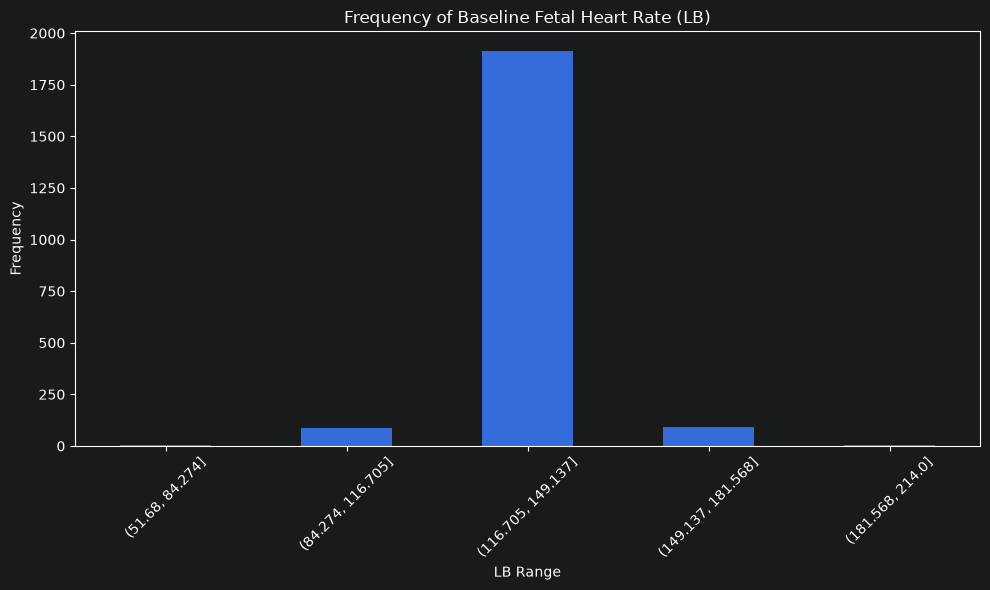

In [20]:
lb_bins = pd.cut(df["LB"], bins=5)

lb_counts = lb_bins.value_counts().sort_index()

plt.figure(figsize=(10, 6))
lb_counts.plot(kind="bar")

plt.title("Frequency of Baseline Fetal Heart Rate (LB)")
plt.xlabel("LB Range")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

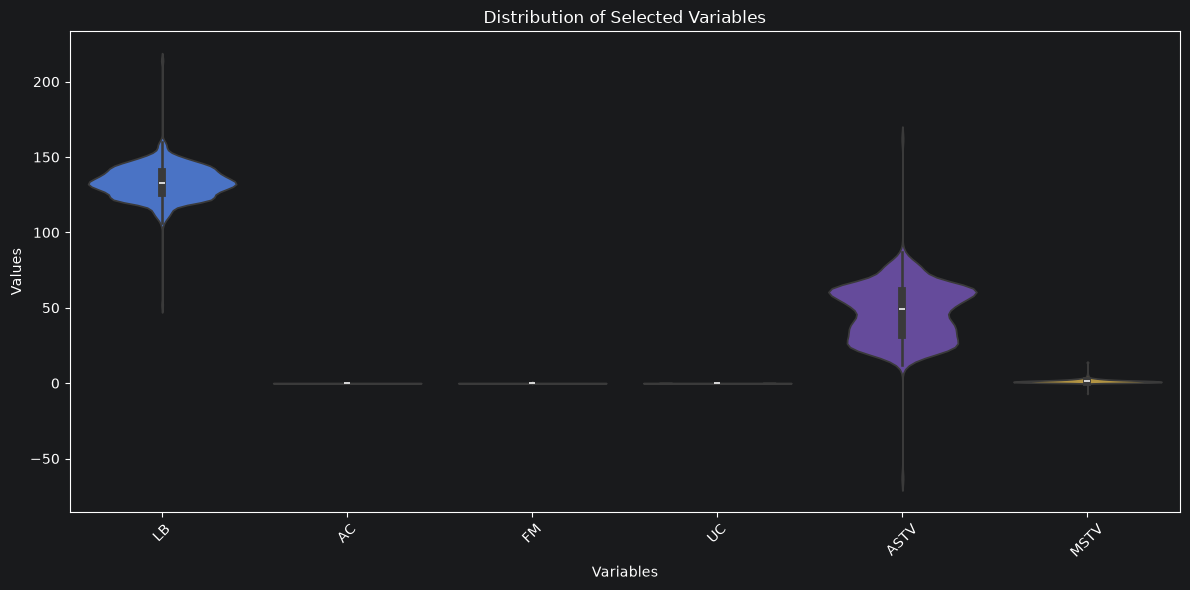

In [21]:
selected_columns = ["LB", "AC", "FM", "UC", "ASTV", "MSTV"]

plt.figure(figsize=(12, 6))
sns.violinplot(data=df[selected_columns])

plt.title("Distribution of Selected Variables")
plt.xlabel("Variables")
plt.ylabel("Values")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [22]:
correlation_matrix = df.corr(numeric_only=True)

correlation_pairs = (
    correlation_matrix
    .where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))
    .stack()
    .sort_values()
)

print("Strongest Negative Correlations:")
print(correlation_pairs.head(5))

print("\nStrongest Positive Correlations:")
print(correlation_pairs.tail(5))

Strongest Negative Correlations:
ALTV  Width   -0.346460
AC    NSP     -0.316941
ASTV  MSTV    -0.293882
MSTV  ALTV    -0.291935
AC    ALTV    -0.271390
dtype: float64

Strongest Positive Correlations:
NSP  ALTV       NaN
     MLTV       NaN
     Width      NaN
     Tendency   NaN
     NSP        NaN
dtype: float64


In [23]:
summary = pd.DataFrame({
    "Mean": df.mean(numeric_only=True),
    "Median": df.median(numeric_only=True),
    "Standard Deviation": df.std(numeric_only=True),
    "IQR": df.quantile(0.75, numeric_only=True) - df.quantile(0.25, numeric_only=True)
})

summary

,Mean,Median,Standard Deviation,IQR
LB,133.343598,133.000000,11.270154,14.000000
AC,0.003219,0.001634,0.004391,0.005650
FM,0.009894,0.000000,0.067540,0.002567
UC,0.004391,0.004484,0.003340,0.004685
DL,0.001895,0.000000,0.003343,0.003289
DS,0.000003,0.000000,0.000142,0.000000
DP,0.000175,0.000000,0.000840,0.000000
ASTV,46.995984,49.000000,18.813973,29.000000
MSTV,1.364378,1.200000,1.173632,1.000000
ALTV,10.285964,0.000000,21.205041,11.000000


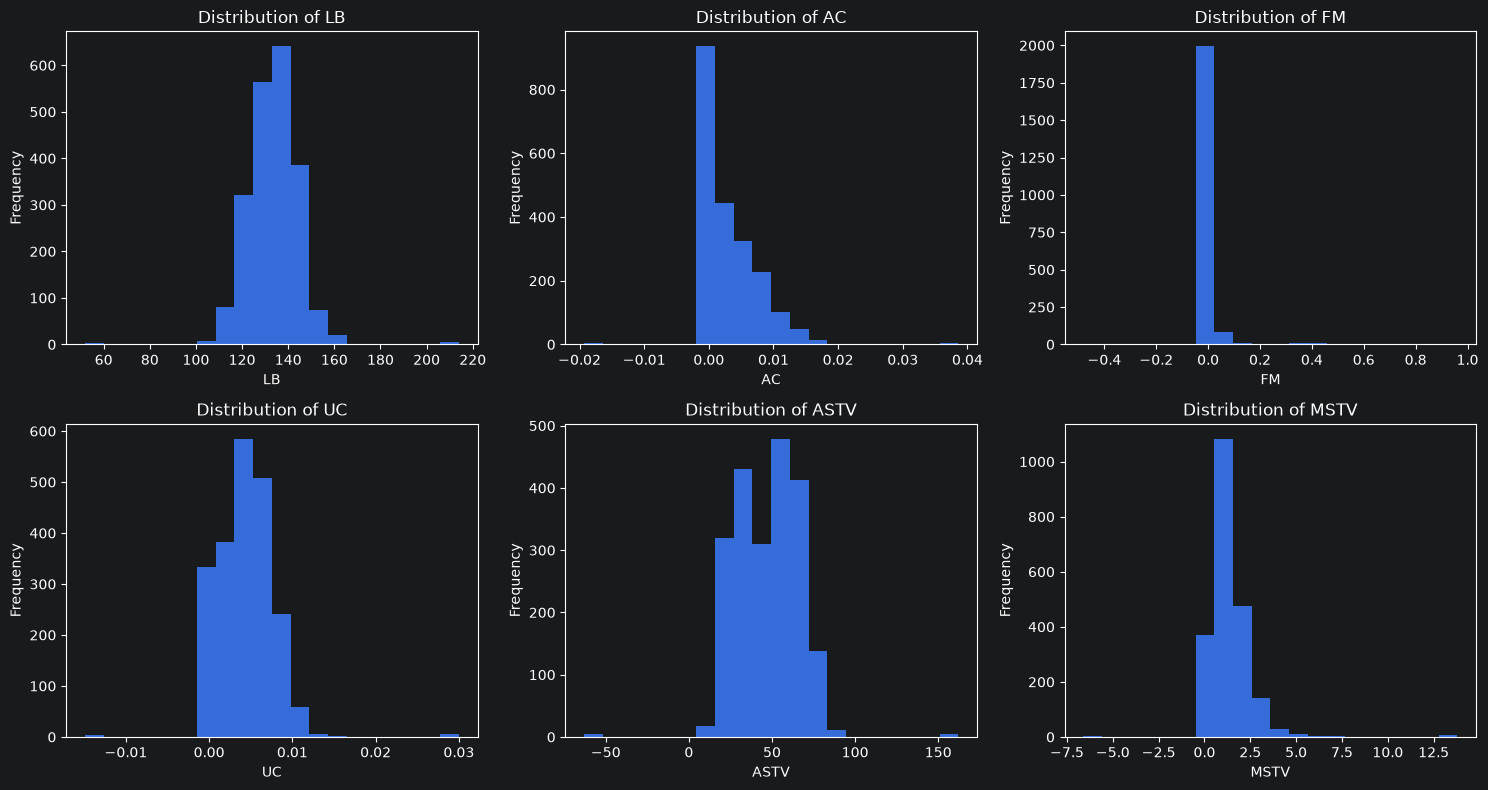

In [24]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

variables = ["LB", "AC", "FM", "UC", "ASTV", "MSTV"]

for ax, column in zip(axes.flat, variables):
    ax.hist(df[column], bins=20)
    ax.set_title(f"Distribution of {column}")
    ax.set_xlabel(column)
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()